<a href="https://colab.research.google.com/github/Ragna1204/Product-Review-Sentiment-Analysis-using-Machine-Learning/blob/main/Product_Review_Sentiment_Analysis_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:

# 2. Create Dataset
data = {
    "review": [
        "This product is amazing and works perfectly",
        "Worst purchase ever totally useless",
        "Very good quality I liked it",
        "Not worth the money",
        "Excellent performance and fast delivery",
        "Terrible experience broke in one day",
        "I am very satisfied with this product",
        "Waste of money do not buy",
        "Good value for money",
        "Poor quality and bad service",
        "Loved it highly recommend",
        "Completely disappointed",
        "Works as expected",
        "Very bad packaging",
        "Fantastic product",
        "Not good at all",
        "Happy with the purchase",
        "It stopped working after a week",
        "Great build quality",
        "Horrible experience",
        "Superb design and excellent performance",
        "Very poor durability",
        "Absolutely loved the product",
        "Not satisfied with the quality",
        "Worth every penny",
        "Do not recommend this product",
        "Really happy with the results",
        "Worst quality I have seen",
        "Amazing experience overall",
        "Completely waste of money",
        "Absolutely fantastic product, exceeded my expectations",
        "Very reliable and works smoothly without any issues",
        "Great quality and excellent performance",
        "I am extremely happy with this purchase",
        "Superb build quality and premium feel",
        "The product works flawlessly and is easy to use",
        "Highly satisfied with the performance",
        "Excellent value for money, totally worth it",
        "Very durable and long lasting product",
        "Impressive features and smooth functionality",
        "Really loved the design and usability",
        "Outstanding product with great support",
        "The performance is top notch and consistent",
        "Very efficient and does exactly what it promises",
        "Brilliant quality, will definitely recommend",
        "Perfect product for daily use",
        "Very happy with the results and performance",
        "Top quality product with great finishing",
        "Works perfectly fine and meets expectations",
        "Good packaging and fast delivery, satisfied",
        "Very poor quality, stopped working quickly",
        "Extremely disappointed with this product",
        "Waste of money, not recommended at all",
        "The product is defective and unreliable",
        "Terrible experience, completely useless",
        "Poor build quality and bad performance",
        "Not worth the price, very disappointing",
        "Stopped working after a few uses",
        "Low quality material and खराब performance",
        "Very frustrating to use, not user friendly",
        "Does not work as advertised",
        "Completely dissatisfied with the purchase",
        "Bad experience, will not buy again",
        "Product arrived damaged and unusable",
        "Very cheap quality, broke easily",
        "Performance is very slow and inconsistent",
        "Not durable at all, failed quickly",
        "Poor customer experience and bad product",
        "Totally useless and not worth buying",
        "Very disappointing results, expected much better"
    ],
    "sentiment": [
        "positive","negative","positive","negative","positive",
        "negative","positive","negative","positive","negative",
        "positive","negative","positive","negative","positive",
        "negative","positive","negative","positive","negative",
        "positive","negative","positive","negative","positive",
        "negative","positive","negative","positive","negative",
        "positive","positive","positive","positive","positive",
        "positive","positive","positive","positive","positive",
        "positive","positive","positive","positive","positive",
        "positive","positive","positive","positive","positive",
        "negative","negative","negative","negative","negative",
        "negative","negative","negative","negative","negative",
        "negative","negative","negative","negative","negative",
        "negative","negative","negative","negative","negative"
    ]
}

df = pd.DataFrame(data)

print("Dataset Preview:\n")
print(df.head())


Dataset Preview:

                                        review sentiment
0  This product is amazing and works perfectly  positive
1          Worst purchase ever totally useless  negative
2                 Very good quality I liked it  positive
3                          Not worth the money  negative
4      Excellent performance and fast delivery  positive


In [ ]:

# 3. Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["cleaned"] = df["review"].apply(preprocess)

print("\nCleaned Text:\n")
print(df[["review", "cleaned"]].head())



Cleaned Text:

                                        review  \
0  This product is amazing and works perfectly   
1          Worst purchase ever totally useless   
2                 Very good quality I liked it   
3                          Not worth the money   
4      Excellent performance and fast delivery   

                               cleaned  
0      product amazing works perfectly  
1  worst purchase ever totally useless  
2                   good quality liked  
3                          worth money  
4  excellent performance fast delivery  


In [ ]:

# 4. Feature Extraction (TF-IDF)
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),   # unigrams + bigrams
    max_features=500,
    min_df=1
)
X = vectorizer.fit_transform(df["cleaned"])
y = df["sentiment"]


In [ ]:

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [ ]:

# 6. Models

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=2000, C=2)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Support Vector Machine
svm = SVC(kernel='linear', C=2)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)


In [ ]:

# 7. Evaluation
print("\n===== MODEL PERFORMANCE =====\n")

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nConfusion Matrix (Naive Bayes):\n", confusion_matrix(y_test, nb_pred))

print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, nb_pred))



===== MODEL PERFORMANCE =====

Naive Bayes Accuracy: 0.7777777777777778
Logistic Regression Accuracy: 0.7222222222222222
SVM Accuracy: 0.7777777777777778

Confusion Matrix (Naive Bayes):
 [[6 3]
 [1 8]]

Classification Report (Naive Bayes):

              precision    recall  f1-score   support

    negative       0.86      0.67      0.75         9
    positive       0.73      0.89      0.80         9

    accuracy                           0.78        18
   macro avg       0.79      0.78      0.78        18
weighted avg       0.79      0.78      0.77        18



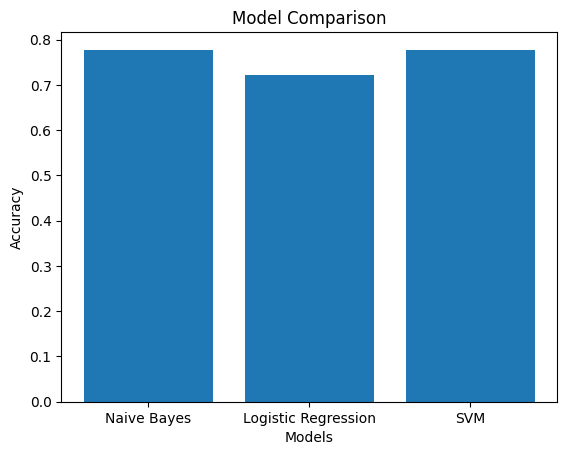

In [ ]:

# 8. Accuracy Comparison Graph
models = ["Naive Bayes", "Logistic Regression", "SVM"]
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()


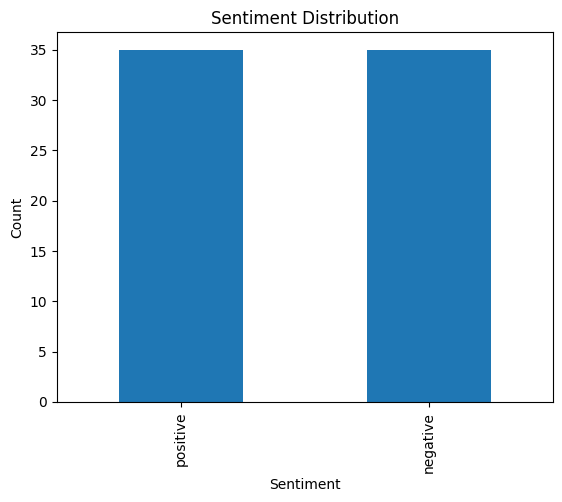

In [ ]:

# 9. Dataset Distribution Graph
df["sentiment"].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

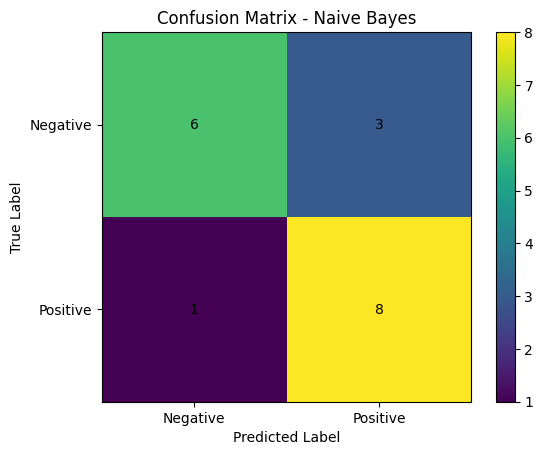

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_pred)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.xticks([0,1], ["Negative", "Positive"])
plt.yticks([0,1], ["Negative", "Positive"])

plt.show()